
Entrenando Decision Tree para QQQ (Baseline)...

 Resultados QQQ:
Train Precision: 0.6087
Test Precision: 0.5926
Train Accuracy: 0.6154
Test Accuracy: 0.5093
Train ROC AUC: 0.5658
Test ROC AUC: 0.5095
Cumulative Return: 0.0533
 Modelo guardado en ../models/DecisionTree_QQQ.pkl


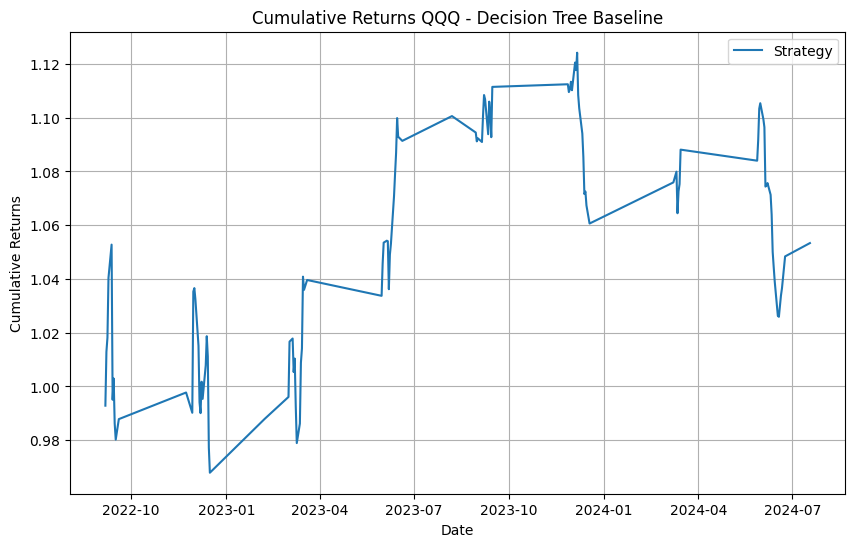


 Entrenando Decision Tree para SPY (Baseline)...

 Resultados SPY:
Train Precision: 0.6163
Test Precision: 0.5238
Train Accuracy: 0.6562
Test Accuracy: 0.4554
Train ROC AUC: 0.6446
Test ROC AUC: 0.4129
Cumulative Return: -0.0296
 Modelo guardado en ../models/DecisionTree_SPY.pkl


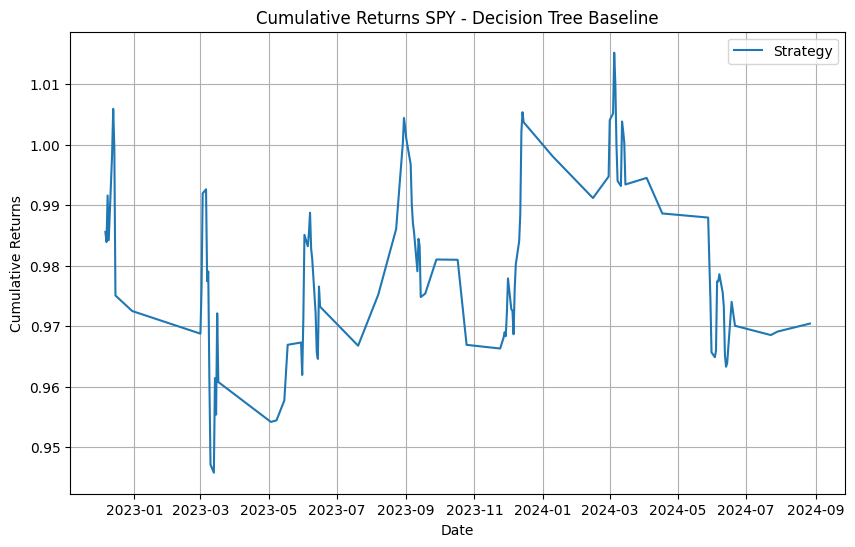

In [2]:
# ===== LIBRERÍAS =====
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from modeling_utils import train_and_evaluate_model, save_model, plot_cumulative_returns

# ===== PATHS =====
path_QQQ = "../data/CLEAN/qqq_to_train.csv"
path_SPY = "../data/CLEAN/spy_to_train.csv"
save_path_QQQ = "../models/DecisionTree_QQQ.pkl"
save_path_SPY = "../models/DecisionTree_SPY.pkl"

# ===== CARGAR DATOS =====
data_QQQ = pd.read_csv(path_QQQ, index_col=0, parse_dates=True)
data_SPY = pd.read_csv(path_SPY, index_col=0, parse_dates=True)

returns_QQQ = data_QQQ['daily_return']
X_QQQ = data_QQQ.drop(columns=["target", "daily_return"])
y_QQQ = data_QQQ["target"]

returns_SPY = data_SPY['daily_return']
X_SPY = data_SPY.drop(columns=["target", "daily_return"])
y_SPY = data_SPY["target"]

# ===== ESCALAR =====
scaler_QQQ = StandardScaler()
X_QQQ_scaled = scaler_QQQ.fit_transform(X_QQQ)

scaler_SPY = StandardScaler()
X_SPY_scaled = scaler_SPY.fit_transform(X_SPY)

# ===== MODELO Árbol de Decisión (Baseline) =====
# Árbol muy simple y regulado para baseline
tree_model = DecisionTreeClassifier(
    max_depth=3,            # Árbol muy pequeño para evitar overfitting
    min_samples_split=50,   # Mínimo de muestras para dividir un nodo
    min_samples_leaf=20,    # Mínimo de muestras en una hoja
    random_state=42
)

# ===== ENTRENAR Y VALIDAR QQQ =====
print("\nEntrenando Decision Tree para QQQ (Baseline)...")
model_QQQ, metrics_QQQ, X_train_QQQ, X_test_QQQ, y_train_QQQ, y_test_QQQ, returns_test_QQQ = train_and_evaluate_model(
    model=tree_model,
    X=X_QQQ_scaled,
    y=y_QQQ,
    returns=returns_QQQ
)

# Mostrar métricas
print("\n Resultados QQQ:")
for metric, value in metrics_QQQ.items():
    print(f"{metric}: {value:.4f}")

# Guardar modelo
save_model(model_QQQ, save_path_QQQ)

# Graficar retornos
plot_cumulative_returns(y_test_QQQ, model_QQQ.predict(X_test_QQQ), returns_test_QQQ, title="Cumulative Returns QQQ - Decision Tree Baseline")


# ===== ENTRENAR Y VALIDAR SPY =====
print("\n Entrenando Decision Tree para SPY (Baseline)...")
model_SPY, metrics_SPY, X_train_SPY, X_test_SPY, y_train_SPY, y_test_SPY, returns_test_SPY = train_and_evaluate_model(
    model=tree_model,
    X=X_SPY_scaled,
    y=y_SPY,
    returns=returns_SPY
)

# Mostrar métricas
print("\n Resultados SPY:")
for metric, value in metrics_SPY.items():
    print(f"{metric}: {value:.4f}")

# Guardar modelo
save_model(model_SPY, save_path_SPY)

# Graficar retornos
plot_cumulative_returns(y_test_SPY, model_SPY.predict(X_test_SPY), returns_test_SPY, title="Cumulative Returns SPY - Decision Tree Baseline")


In [2]:
# En el modelo baseline de Árbol de Decisión, el desempeño para 
#QQQ mostró un resultado aceptable dado su nivel de simplicidad,
#alcanzando una precisión de entrenamiento de 0.5995 y de prueba de 0.6667, 
#junto con un retorno acumulado positivo de 19.89%, reflejado en un crecimiento sostenido aunque algo volátil en la curva de
#retornos. Sin embargo, para SPY, el árbol de decisión fue menos efectivo,
#logrando una precisión de prueba de apenas 0.4940 y un retorno acumulado levemente negativo de -0.94%,
#con una curva de retornos que presenta caídas importantes hacia el segundo semestre de 2024.
#Estos resultados refuerzan que, aunque los árboles simples pueden capturar señales básicas, 
#carecen de suficiente capacidad predictiva en series financieras más ruidosas como SPY, 
#mostrando también una tendencia a overfitting moderado, especialmente visible en la discrepancia de métricas entre el
#entrenamiento y la prueba.
